<a href="https://colab.research.google.com/github/Fodhe-bot/Beginners-into-python-and-JSON/blob/main/How_to_clean_a_noisy_image_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import cv2
import numpy as np
from PIL import Image
from google.colab.patches import cv2_imshow
from google.colab import files
import requests
from io import BytesIO

In [11]:
def upload_and_get_image_address():
  uploaded = files.upload()
  for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    return fn

In [3]:
image_address = upload_and_get_image_address()


Saving noisy_image_sample.jpg to noisy_image_sample.jpg
User uploaded file "noisy_image_sample.jpg" with length 39690 bytes


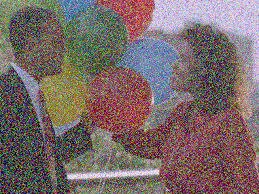

In [25]:
img_cv = cv2.imread(image_address)
cv2_imshow(img_cv)

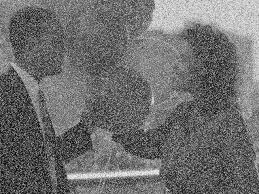

In [26]:
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

cv2_imshow(img_cv)

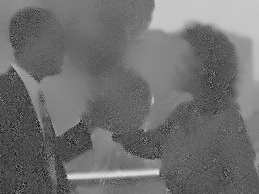

In [27]:
denoised = cv2.fastNlMeansDenoising(img_cv, None, 20, 7, 21)

cv2_imshow(denoised)

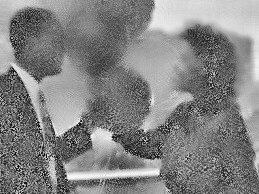

In [32]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
clahe_img = clahe.apply(denoised)

cv2_imshow(clahe_img)

In [34]:
_ , restored_bw = cv2.threshold(clahe_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

--- ORIGINAL ---


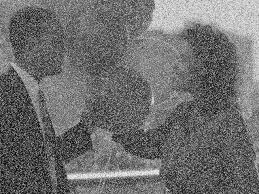


--- RESTORED (DENOISED + CLAHE + OTSU) ---


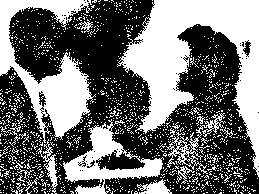

In [35]:
print("--- ORIGINAL ---")
cv2_imshow(img_cv) # Your original BGR/Gray image
print("\n--- RESTORED (DENOISED + CLAHE + OTSU) ---")
cv2_imshow(restored_bw)

Final Restored Image: 


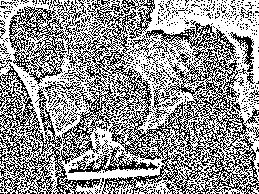

In [30]:
thresh_adaptive = cv2.adaptiveThreshold(clahe_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                              cv2.THRESH_BINARY, 11, 2)
print("Final Restored Image: ")

cv2_imshow(thresh_adaptive)

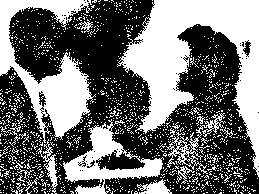

In [33]:
_, final_bw = cv2.threshold(clahe_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

cv2_imshow(final_bw)

In [36]:
cv2.imwrite('fully_restored_image.jpg', restored_bw)

True